### Utils

In [33]:
import numpy as np
import torch
import scipy.sparse as sp
import torch_geometric.datasets
import torch.nn as nn

In [24]:
def encode_onehot(labels):
    classes = set(labels)
    classes_dict = {c: np.identity(len(classes))[i, :] for i, c in
                    enumerate(classes)}
    labels_onehot = np.array(list(map(classes_dict.get, labels)),
                             dtype=np.int32)
    return labels_onehot

In [18]:
def load_data(path="/Users/poorvaichandrasen/Downloads", dataset="Cora"):
    """Load citation network dataset (cora only for now)"""
    print('Loading {} dataset...'.format(dataset))

    idx_features_labels = np.genfromtxt("{}{}.content".format(path, dataset),
                                        dtype=np.dtype(str))
    features = sp.csr_matrix(idx_features_labels[:, 1:-1], dtype=np.float32)
    labels = encode_onehot(idx_features_labels[:, -1])
# Created arrays, now graph
    
    idx = np.array(idx_features_labels[:, 0], dtype=np.int32)
    idx_map = {j: i for i, j in enumerate(idx)}
    #creates a dictionary which maps each 
    edges_unordered = np.genfromtxt("{}{}.cites".format(path, dataset),
                                    dtype=np.int32)
    #What does the edges unordered dataset look like
    
    edges = np.array(list(map(idx_map.get, edges_unordered.flatten())),
                     dtype=np.int32).reshape(edges_unordered.shape)
    adj = sp.coo_matrix((np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
                        shape=(labels.shape[0], labels.shape[0]),
                        dtype=np.float32)

    # build symmetric adjacency matrix
    adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

    features = normalize(features)
    adj = normalize(adj + sp.eye(adj.shape[0]))

    idx_train = range(140)
    idx_val = range(200, 500)
    idx_test = range(500, 1500)

    features = torch.FloatTensor(np.array(features.todense()))
    labels = torch.LongTensor(np.where(labels)[1])
    adj = sparse_mx_to_torch_sparse_tensor(adj)

    idx_train = torch.LongTensor(idx_train)
    idx_val = torch.LongTensor(idx_val)
    idx_test = torch.LongTensor(idx_test)

    return adj, features, labels, idx_train, idx_val, idx_test

In [5]:
def normalize(mx):
    """Row-normalize sparse matrix"""
    rowsum = np.array(mx.sum(1))
    r_inv = np.power(rowsum, -1).flatten()
    r_inv[np.isinf(r_inv)] = 0.
    r_mat_inv = sp.diags(r_inv)
    mx = r_mat_inv.dot(mx)
    return mx

In [6]:
def accuracy(output, labels):
    preds = output.max(1)[1].type_as(labels)
    correct = preds.eq(labels).double()
    correct = correct.sum()
    return correct / len(labels)

In [7]:
def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(
        np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

In [8]:
class GCN(nn.Module):
    def __init__(self, nfeat, nhid, nclass, dropout):
        super(GCN, self).__init__()

        self.gc1 = GraphConvolution(nfeat, nhid)
        self.gc2 = GraphConvolution(nhid, nclass)
        self.dropout = dropout

    def forward(self, x, adj):
        x = F.relu(self.gc1(x, adj))
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.gc2(x, adj)
        return F.log_softmax(x, dim=1)

#### To explain enumerate

In [83]:
mylist = np.random.randint(0,10,(4,10))
mylist

{0: [1], 2: [3], 4: [5]}

In [77]:
for i, j in enumerate(mylist):
    print(i,j)

0 [4 4 6 7 1 7 1 1 0 6]
1 [5 1 2 7 6 1 0 3 7 7]
2 [3 8 5 2 2 3 0 9 1 0]
3 [3 5 2 7 8 6 0 3 4 6]


In [88]:
mydict = {0:[100,1000,10000], 1:[2,4,8], 2:[0,0,0], 3:[0,1,1]}
mydict.get(1)

[2, 4, 8]

### models

In [20]:
features.shape

NameError: name 'features' is not defined

In [226]:
labels.shape

torch.Size([2708])

In [332]:
model = GCN(1433, 16, 7, 0.5)

In [260]:
print(model)

GCN(
  (gc1): GraphConvolution (1433 -> 16)
  (gc2): GraphConvolution (16 -> 7)
)


In [257]:
import math

from torch.nn.parameter import Parameter
from torch.nn.modules.module import Module


class GraphConvolution(Module):
    """
    Simple GCN layer, similar to https://arxiv.org/abs/1609.02907
    """
    def __init__(self, in_featuresx, out_features, bias=True):
        super(GraphConvolution, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = Parameter(torch.FloatTensor(in_features, out_features)) # Weight matrox of given size is asscosciated with each layer
        if bias:
            self.bias = Parameter(torch.FloatTensor(out_features)) #creates a bias matrix assosciated with that layer
        else:
            self.register_parameter('bias', None)
        self.reset_parameters() #initialises the parameters

    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.weight.size(1)) #num rows
        self.weight.data.uniform_(-stdv, stdv) #fills weight matrix elements to random values 
        if self.bias is not None:
            self.bias.data.uniform_(-stdv, stdv) #fills bias matrix with random values

    def forward(self, input, adj):
        support = torch.mm(input, self.weight)
        output = torch.spmm(adj, support)
        if self.bias is not None:
            return output + self.bias
        else:
            return output

    def __repr__(self):
        return self.__class__.__name__ + ' (' \
               + str(self.in_features) + ' -> ' \
               + str(self.out_features) + ')'

In [208]:
adj, features, labels, idx_train, idx_val, idx_test = load_data()

Loading Cora dataset...


In [340]:
print(model)

GCN(
  (gc1): GraphConvolution (1433 -> 16)
  (gc2): GraphConvolution (16 -> 7)
)


In [292]:
#Training
device = torch.device("cpu")

model = GCN(1433, 16, 7, 0.5)
model = model.to(device)

learning_rate = 0.05
decay = 5e-4
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=learning_rate, 
                             weight_decay=decay)
# Define loss function (CrossEntropyLoss for Classification Problems with 
# probability distributions)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      optimizer.zero_grad() 
      # Use all data as input, because all nodes have node features
      out = model(features, adj)  
      # Only use nodes with labels available for loss calculation --> mask
      loss = criterion(out[idx_train], labels[idx_train])  
      loss.backward() 
      optimizer.step()
      return loss

def test():
      model.eval()
      out = model(features, adj)
      # Use the class with highest probability.
      pred = out.argmax(dim=1)  
      # Check against ground-truth labels.
      test_correct = pred[idx_test] == labels[idx_test]  
      # Derive ratio of correct predictions.
      test_acc = int(test_correct.sum()) / int(idx_test.sum())  
      return test_acc

losses = []
for epoch in range(0, 1001):
    loss = train()
    losses.append(loss)
    if epoch % 100 == 0:
      print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

Epoch: 000, Loss: 1.9106
Epoch: 100, Loss: 0.3403
Epoch: 200, Loss: 0.2467
Epoch: 300, Loss: 0.2384
Epoch: 400, Loss: 0.2513
Epoch: 500, Loss: 0.2304
Epoch: 600, Loss: 0.1927
Epoch: 700, Loss: 0.2329
Epoch: 800, Loss: 0.1893
Epoch: 900, Loss: 0.1993
Epoch: 1000, Loss: 0.2226


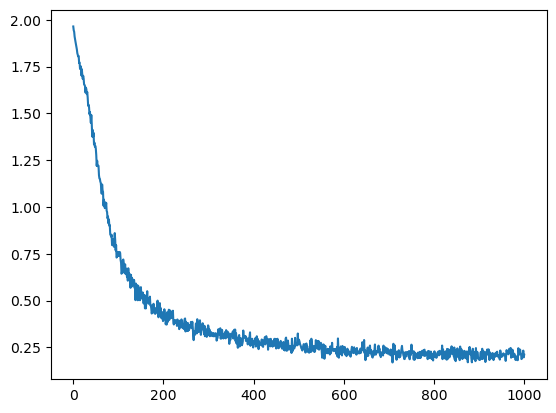

In [287]:
import matplotlib.pyplot as plt
plot = plt.plot (loss_indices, losses_float)

In [294]:
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.0008


tensor([[1.3386, 1.2117, 1.3825],
        [1.9834, 1.6632, 1.9389],
        [1.5684, 1.2784, 1.4675]])
tensor([[2.3302, 1.6222, 1.7525],
        [1.8481, 1.2761, 1.3642],
        [1.2632, 0.9476, 0.8631]])


# New attempt

### Dataset

In [177]:
from torch_geometric.datasets import Planetoid
dataset = Planetoid(root='data/Planetoid', name='Cora')

Processing...
Done!


In [175]:
print(dataset[0])


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


AttributeError: 'Planetoid' object has no attribute 'shape'